
1. 在运行反向传播函数之后，立即再次运行它，看看会发生什么。
1. 在控制流的例子中，我们计算`d`关于`a`的导数，如果将变量`a`更改为随机向量或矩阵，会发生什么？
1. 重新设计一个求控制流梯度的例子，运行并分析结果。
1. 使$f(x)=\sin(x)$，绘制$f(x)$和$\frac{df(x)}{dx}$的图像，其中后者不使用$f'(x)=\cos(x)$。

In [1]:
import torch

x = torch.tensor(3.0, requires_grad=True)
y = x**2

y.backward()
y.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

backward()只能运行一次，除非计算图被释放retain_graph=True，如下所示

In [2]:
import torch

x = torch.tensor(3.0, requires_grad=True)
y = x**2
y.backward(retain_graph=True)
y.backward()

In [3]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [4]:
a = torch.randn(3, requires_grad=True)
d = f(a)
d.backward()

RuntimeError: grad can be implicitly created only for scalar outputs

将a改为随机向量或者矩阵，函数正常执行，但此时返回的d不是标量而是向量或矩阵，不能直接调用d.backward()，要先将其转换成标量进行降维，并且最终得到的梯度与a形状相同

In [5]:
a = torch.randn(3, requires_grad=True)
d = f(a)

d.backward(torch.ones_like(d))
print(a.grad)

tensor([51200., 51200., 51200.])


In [7]:
def g(a):
    b = a
    while b.abs() < 10:
        b = b * 3
    if b > 0:
        return b
    else:
        return b ** 2

a = torch.tensor(-0.5, requires_grad=True)
d = g(a)
d.backward()
print(d)
print(a.grad)

tensor(182.2500, grad_fn=<PowBackward0>)
tensor(-729.)


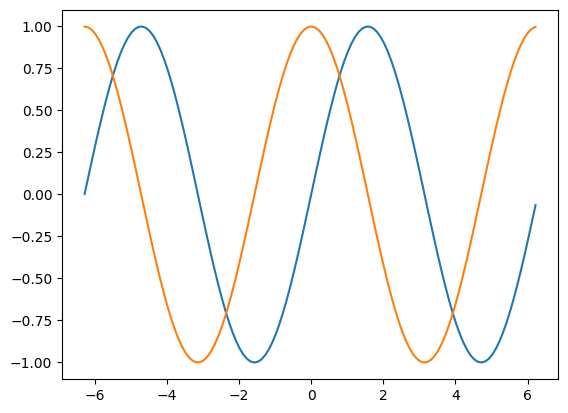

In [10]:
import matplotlib.pyplot as plt

x = torch.arange(-6.28,6.28,0.1, requires_grad=True)

y = torch.sin(x)

y.sum().backward()

plt.plot(x.detach(), y.detach(), label="sin(x)")
plt.plot(x.detach(), x.grad, label="df/dx (autograd)")
